# Relationship Between PM2.5 and O3 (2020–2023)
This notebook investigates the statistical relationship between PM2.5 and O3 concentrations.
Objective:
- Merge pollutant datasets
- Analyze correlation
- Visualize pollutant interaction
- Evaluate suitability of O3 as a predictive feature for PM2.5 modeling

## Loading PM2.5 and O3 Master Datasets

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pm25 = pd.read_csv("../../data/master/PM25_2020 cleaned Master_20_23.csv")
o3 = pd.read_csv("../../data/master/O3_2020 cleaned Master_20_23.csv")

# Convert types
pm25["Date"] = pd.to_datetime(pm25["Date"])
o3["Date"] = pd.to_datetime(o3["Date"])

pm25["PM25"] = pd.to_numeric(pm25["PM25"], errors="coerce")
o3["O3"] = pd.to_numeric(o3["O3"], errors="coerce")
pm25.shape, o3.shape

((386424, 6), (338222, 6))

## Merging PM2.5 and O3 Data

In [12]:
merged = pd.merge(pm25, o3, on=["City", "Date"], how="inner")
merged.head()
merged.shape

(763308, 10)

## Removing Missing Values

In [15]:
merged = merged.dropna(subset=["PM25", "O3"])
merged.shape

(603829, 10)

## Scatter Plot: PM2.5 vs O3

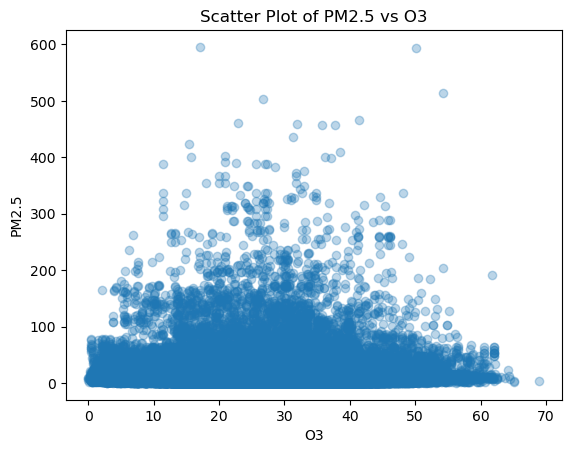

In [18]:
plt.figure()
plt.scatter(merged["O3"], merged["PM25"], alpha=0.3)
plt.xlabel("O3")
plt.ylabel("PM2.5")
plt.title("Scatter Plot of PM2.5 vs O3")
plt.show()


## Correlation Analysis

In [21]:
corr = merged[["PM25", "O3"]].corr()
corr

,PM25,O3
PM25,1.000000,-0.019041
O3,-0.019041,1.000000


## Correlation Heatmap

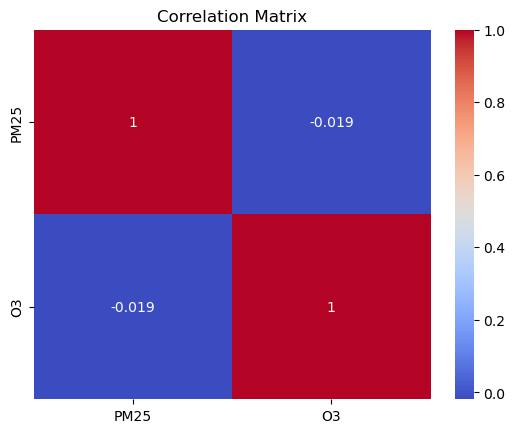

In [24]:
plt.figure()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


##  Regression Line Visualization

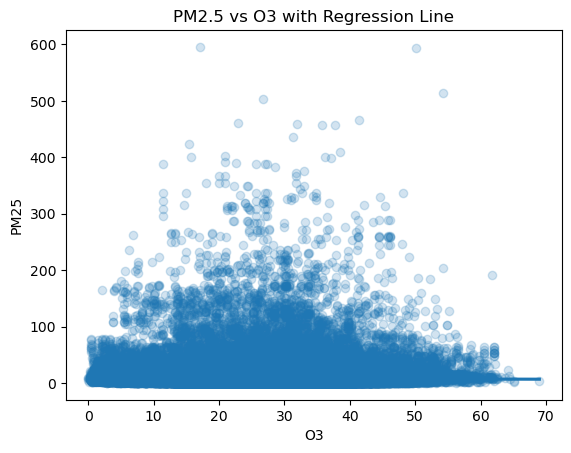

In [28]:
plt.figure()
sns.regplot(x="O3", y="PM25", data=merged, scatter_kws={"alpha":0.2})
plt.title("PM2.5 vs O3 with Regression Line")
plt.show()


## Interpretation of PM2.5–O3 Relationship
The Pearson correlation between PM2.5 and O3 is approximately -0.019, indicating no meaningful linear relationship between the two pollutants.
The scatter plot and regression line further confirm the absence of a clear trend.
This suggests that O3 alone is not a strong predictor of PM2.5 concentrations.
The two pollutants are influenced by different atmospheric mechanisms, with PM2.5 strongly impacted by wildfire and combustion sources, while O3 is driven by photochemical reactions.